### Here, we understand TENX95 biologically and structurally before patch extraction or model training

The goal of this notebook is to produce:
- Clean spot metadata table
- Expression matrix summary
- Spatial coordinate summary
- Gene-expression EDA plots
- Highly variable gene list
- Spot overlay on tissue thumbnail
- Processed outputs saved for future

In [20]:
# Setup libraries and paths
from pathlib import Path
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Data handling libraries
import scanpy as sc
import anndata as ad

# Image processing libraries:
from PIL import Image

# Project root detection
def find_project_root(start_path=None, project_name="HistoGeneAlign"):
    if start_path is None:
        start_path = Path.cwd()
    start_path = Path(start_path).resolve()

    for p in [start_path] + list(start_path.parents):
        if p.name == project_name:
            return p

    # fallback: detect by expected folders
    for p in [start_path] + list(start_path.parents):
        if (p / "data").exists() and (p / "notebooks").exists():
            return p

    raise RuntimeError("Could not find project root. Check your working directory.")

# Definig paths
PROJECT_ROOT = find_project_root()
RAW_DIR = PROJECT_ROOT / "data" / "raw" / "hest"
PROCESSED_DIR = PROJECT_ROOT / "data" / "processed"
FIGURE_DIR = PROJECT_ROOT / "outputs" / "figures"

PROCESSED_DIR.mkdir(parents=True, exist_ok=True)
FIGURE_DIR.mkdir(parents=True, exist_ok=True)

SAMPLE_ID = "TENX95"

H5AD_PATH = RAW_DIR / "st" / f"{SAMPLE_ID}.h5ad"
META_PATH = RAW_DIR / "metadata" / f"{SAMPLE_ID}.json"
THUMBNAIL_PATH = RAW_DIR / "thumbnails" / f"{SAMPLE_ID}_downscaled_fullres.jpeg"

# Checking if files exist
print("PROJECT_ROOT:", PROJECT_ROOT)
print("H5AD exists:", H5AD_PATH.exists(), H5AD_PATH)
print("Metadata exists:", META_PATH.exists(), META_PATH)
print("Thumbnail exists:", THUMBNAIL_PATH.exists(), THUMBNAIL_PATH)

PROJECT_ROOT: C:\Users\Hareen\Desktop\HistoGeneAlign
H5AD exists: True C:\Users\Hareen\Desktop\HistoGeneAlign\data\raw\hest\st\TENX95.h5ad
Metadata exists: True C:\Users\Hareen\Desktop\HistoGeneAlign\data\raw\hest\metadata\TENX95.json
Thumbnail exists: True C:\Users\Hareen\Desktop\HistoGeneAlign\data\raw\hest\thumbnails\TENX95_downscaled_fullres.jpeg


### Loading Metadata & AnnData

In [2]:
with open(META_PATH, "r") as f:
    metadata = json.load(f)

adata = sc.read_h5ad(H5AD_PATH)

print("Metadata keys:")
print(list(metadata.keys()))

print("\nAnnData object:")
print(adata)

print("\nShape:")
print("Spots:", adata.n_obs)
print("Genes:", adata.n_vars)

print("\nobs columns:")
print(list(adata.obs.columns)[:30])

print("\nvar columns:")
print(list(adata.var.columns)[:30])

print("\nobsm keys:")
print(list(adata.obsm.keys()))

Metadata keys:
['pixel_size_um_embedded', 'run_name', 'run_start_time', 'region_name', 'preservation_method', 'num_cells', 'transcripts_per_cell', 'transcripts_per_100um', 'cassette_name', 'slide_id', 'panel_design_id', 'panel_name', 'panel_organism', 'panel_tissue_type', 'panel_num_targets_predesigned', 'panel_num_targets_custom', 'pixel_size', 'instrument_sn', 'instrument_sw_version', 'analysis_sw_version', 'experiment_uuid', 'cassette_uuid', 'roi_uuid', 'z_step_size', 'well_uuid', 'images', 'xenium_explorer_files', 'pixel_size_um_estimated', 'spot_diameter', 'inter_spot_dist', 'spots_under_tissue', 'adata_nb_col', 'fullres_px_width', 'fullres_px_height', 'dataset_title', 'id', 'image_filename', 'organ', 'disease_state', 'oncotree_code', 'species', 'patient', 'st_technology', 'data_publication_date', 'license', 'study_link', 'download_page_link1', 'nb_genes', 'treatment_comment', 'magnification', 'tissue', 'disease_comment', 'subseries']

AnnData object:
AnnData object with n_obs × n

The TENX95 spatial transcriptomics dataset loaded successfully as an `AnnData` object, which confirms that the main molecular data source is usable for the next stages of the HistoGeneAlign pipeline.

The object has:
- **11,845 spatial spots**
- **541 genes**
- **1 spatial coordinate matrix stored in `adata.obsm["spatial"]`**

This means each row represents one spatial transcriptomics spot, and each column represents one gene-expression feature.

| Component | Location in AnnData | Meaning |
|---|---|---|
| Spot-level metadata | `adata.obs` | Contains per-spot information such as tissue status, full-resolution pixel coordinates, array coordinates, total counts, and detected gene counts |
| Gene-level metadata | `adata.var` | Contains per-gene quality/statistical summaries such as mean counts, dropout percentage, and total counts |
| Expression matrix | `adata.X` | Stores the spot-by-gene expression values |
| Spatial coordinates | `adata.obsm["spatial"]` | Stores the x/y spatial location of each spot |
| Spatial metadata | `adata.uns["spatial"]` | Stores additional spatial-image-related metadata |

The dataset is already structured in the correct format for multimodal alignment. The spatial coordinates are available in two places:
1. `adata.obs["pxl_col_in_fullres"]` and `adata.obs["pxl_row_in_fullres"]`
2. `adata.obsm["spatial"]`

For this project, the safest primary source for coordinates is:
`adata.obsm["spatial"]`

### Building the clean spot metadata table

In [8]:
if "spatial" not in adata.obsm:
    raise KeyError("adata.obsm['spatial'] not found. Cannot build spatial metadata table.")

coords = adata.obsm["spatial"]

spot_metadata = pd.DataFrame({
    "sample_id": SAMPLE_ID,
    "spot_id": adata.obs_names.astype(str),
    "x": coords[:, 0],
    "y": coords[:, 1],
    "expression_available": True,
    "coordinate_available": True,
    "wsi_available": (RAW_DIR / "wsis" / f"{SAMPLE_ID}.tif").exists(),
    "patch_h5_available": (RAW_DIR / "patches" / f"{SAMPLE_ID}.h5").exists(),
})

display(spot_metadata.head())

print("Spot metadata shape:", spot_metadata.shape)
print("\nCoordinate summary:")
display(spot_metadata[["x", "y"]].describe())

spot_metadata_path = PROCESSED_DIR / f"{SAMPLE_ID}_spot_metadata.csv"
spot_metadata.to_csv(spot_metadata_path, index=False)

print("Saved:", spot_metadata_path)

,sample_id,spot_id,x,y,expression_available,coordinate_available,wsi_available,patch_h5_available
0,TENX95,000x000,249.515782,263.81301,True,True,True,True
1,TENX95,000x001,720.104017,263.81301,True,True,True,True
2,TENX95,000x002,1190.692253,263.81301,True,True,True,True
3,TENX95,000x003,1661.280488,263.81301,True,True,True,True
4,TENX95,000x004,2131.868723,263.81301,True,True,True,True


Spot metadata shape: (11845, 8)

Coordinate summary:


,x,y
count,11845.000000,11845.000000
mean,24249.515782,27087.342422
std,13992.184764,15622.487867
min,249.515782,263.813010
25%,12014.221664,13440.283598
50%,24249.515782,27087.342422
75%,36484.809900,40734.401245
max,48249.515782,53910.871833


Saved: C:\Users\Hareen\Desktop\HistoGeneAlign\data\processed\TENX95_spot_metadata.csv


The clean spot metadata table was created successfully for the TENX95 sample. The table contains **11,845 spatial spots** and **8 metadata columns**, meaning every spot in the `AnnData` object has been converted into a structured tabular format that can be reused in later stages of the project.

Each row represents one spatial transcriptomics spot. The first few rows show that every spot has a valid:
- `sample_id`
- `spot_id`
- `x` coordinate
- `y` coordinate
- expression availability flag
- coordinate availability flag

This confirms that the molecular branch now has a reliable spot-level index.


### Expression matrix diagnostics

In [9]:
X = adata.X

print("Expression matrix type:", type(X))
print("Expression matrix shape:", X.shape)

# Handle sparse or dense matrix
if hasattr(X, "toarray"):
    X_sample = X[:1000].toarray()
    nonzero_count = X.nnz
    total_values = X.shape[0] * X.shape[1]
else:
    X_sample = np.asarray(X[:1000])
    nonzero_count = np.count_nonzero(X)
    total_values = X.size

sparsity = 1 - (nonzero_count / total_values)

print(f"Nonzero values: {nonzero_count:,}")
print(f"Total values: {total_values:,}")
print(f"Sparsity: {sparsity:.4f}")
print(f"Min expression in sample: {X_sample.min():.4f}")
print(f"Max expression in sample: {X_sample.max():.4f}")
print(f"Mean expression in sample: {X_sample.mean():.4f}")

Expression matrix type: <class 'numpy.ndarray'>
Expression matrix shape: (11845, 541)
Nonzero values: 2,292,200
Total values: 6,408,145
Sparsity: 0.6423
Min expression in sample: 0.0000
Max expression in sample: 1254.0000
Mean expression in sample: 1.4918


The expression matrix was loaded successfully as a dense NumPy array.

### Library Size Distribution

,library_size,detected_genes
count,11845.000000,11845.000000
mean,7331.704517,193.516252
std,6410.823856,135.146799
min,0.000000,0.000000
25%,27.000000,21.000000
50%,7880.000000,278.000000
75%,12962.000000,301.000000
max,24150.000000,374.000000


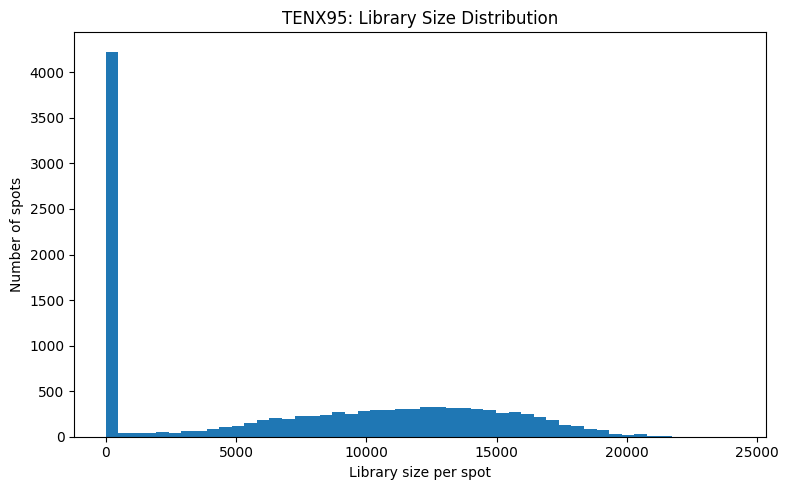

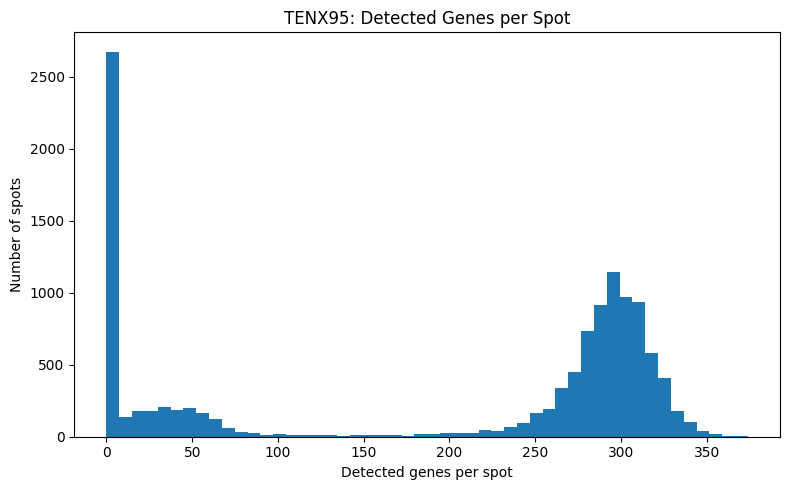

In [10]:
if hasattr(adata.X, "toarray"):
    library_size = np.asarray(adata.X.sum(axis=1)).ravel()
    detected_genes = np.asarray((adata.X > 0).sum(axis=1)).ravel()
else:
    library_size = adata.X.sum(axis=1)
    detected_genes = (adata.X > 0).sum(axis=1)

spot_metadata["library_size"] = library_size
spot_metadata["detected_genes"] = detected_genes

display(spot_metadata[["library_size", "detected_genes"]].describe())

plt.figure(figsize=(8, 5))
plt.hist(library_size, bins=50)
plt.xlabel("Library size per spot")
plt.ylabel("Number of spots")
plt.title(f"{SAMPLE_ID}: Library Size Distribution")
plt.tight_layout()
plt.savefig(FIGURE_DIR / f"{SAMPLE_ID}_library_size_distribution.png", dpi=300)
plt.show()

plt.figure(figsize=(8, 5))
plt.hist(detected_genes, bins=50)
plt.xlabel("Detected genes per spot")
plt.ylabel("Number of spots")
plt.title(f"{SAMPLE_ID}: Detected Genes per Spot")
plt.tight_layout()
plt.savefig(FIGURE_DIR / f"{SAMPLE_ID}_detected_genes_distribution.png", dpi=300)
plt.show()

The two QC plots summarize the spot-level transcriptomic quality of the TENX95 sample. Together, they show how much molecular signal each spatial spot contains and how many genes are detected per spot.

The library size plot shows the total expression count per spatial spot. A clear pattern appears:

- A very large group of spots has library size close to **0**
- The remaining tissue-containing spots form a broad distribution mainly between approximately **5,000 and 18,000 total counts**
- A smaller number of spots extend beyond **20,000 counts**

This indicates that the dataset likely contains a mixture of, low-signal / non-tissue / background spots + valid tissue spots with strong transcriptomic signal.


The detected-gene plot shows how many genes have nonzero expression in each spatial spot. The distribution has two visible groups:

1. Low-quality / low-signal spots
    - Many spots have close to 0 detected genes
    - Some have fewer than approximately 50 detected genes
2. High-quality tissue spots
    - A strong cluster appears around 270–320 detected genes per spot
    - This group likely represents the biologically useful tissue region

This confirms that the dataset contains many valid spatial spots with strong molecular coverage, but also a large low-signal population that needs filtering.

### Gene level summary

In [11]:
if hasattr(adata.X, "toarray"):
    gene_mean = np.asarray(adata.X.mean(axis=0)).ravel()
    gene_nonzero = np.asarray((adata.X > 0).sum(axis=0)).ravel()
else:
    gene_mean = adata.X.mean(axis=0)
    gene_nonzero = (adata.X > 0).sum(axis=0)

gene_summary = pd.DataFrame({
    "gene": adata.var_names.astype(str),
    "mean_expression": gene_mean,
    "nonzero_spots": gene_nonzero,
})

gene_summary["nonzero_fraction"] = gene_summary["nonzero_spots"] / adata.n_obs

gene_summary = gene_summary.sort_values("mean_expression", ascending=False)

display(gene_summary.head(20))

gene_summary_path = PROCESSED_DIR / f"{SAMPLE_ID}_gene_summary.csv"
gene_summary.to_csv(gene_summary_path, index=False)

print("Saved:", gene_summary_path)

,gene,mean_expression,nonzero_spots,nonzero_fraction
129,GATA3,344.600929,8940,0.754749
371,SERPINA3,304.008189,8522,0.719460
128,CLIC6,265.256311,8816,0.744280
164,ANKRD30A,237.702659,8924,0.753398
4,LUM,212.443985,8452,0.713550
66,MYBPC1,208.873871,8482,0.716083
271,TPD52,197.225749,8941,0.754833
163,FLNB,170.609033,8310,0.701562
236,POSTN,165.190038,8550,0.721824
1,RUNX1,156.311102,8391,0.708400


Saved: C:\Users\Hareen\Desktop\HistoGeneAlign\data\processed\TENX95_gene_summary.csv


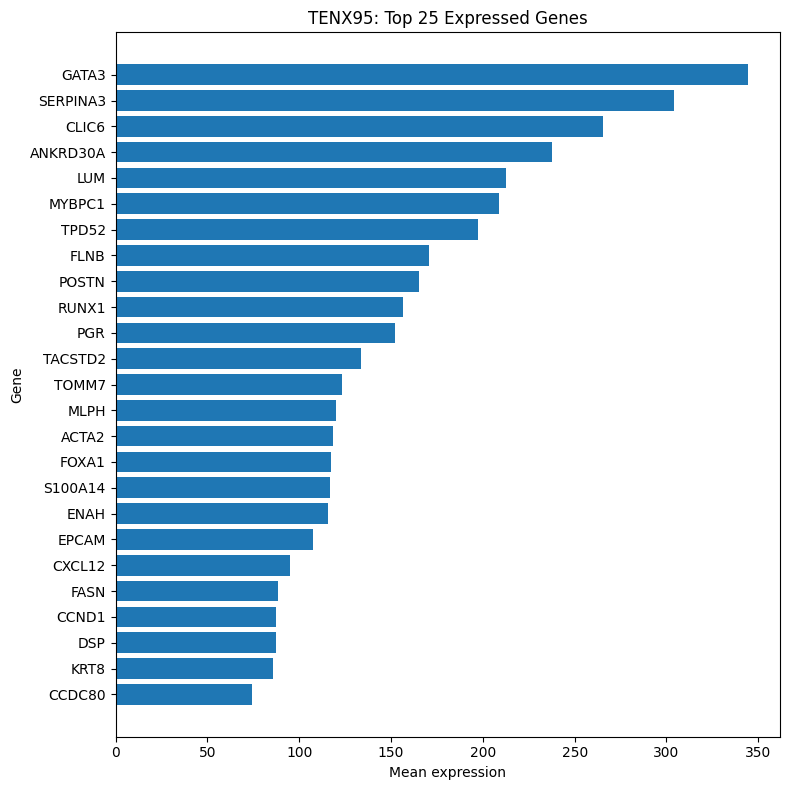

In [12]:
# ============================================================
# Top expressed genes
# ============================================================

top_n = 25
top_genes = gene_summary.head(top_n).iloc[::-1]

plt.figure(figsize=(8, 8))
plt.barh(top_genes["gene"], top_genes["mean_expression"])
plt.xlabel("Mean expression")
plt.ylabel("Gene")
plt.title(f"{SAMPLE_ID}: Top {top_n} Expressed Genes")
plt.tight_layout()
plt.savefig(FIGURE_DIR / f"{SAMPLE_ID}_top_expressed_genes.png", dpi=300)
plt.show()

This plot shows the **top 25 genes ranked by mean expression across all TENX95 spatial spots**. These genes represent the strongest average transcriptomic signals in the sample and give an early biological profile of the tissue before modeling.

Biologically, what these mean are:

| Gene | Biological Interpretation | Project Relavance |
|---|---|---|
| `GATA3` | Transcription factor commonly associated with epithelial differentiation, especially breast and urothelial epithelial programs | Strong epithelial identity signal; may align with glandular/epithelial morphology in H&E |
| `SERPINA3` | Acute-phase/inflammation-associated serine protease inhibitor; often linked to inflammatory or stress-response biology | May reflect inflammatory microenvironment or tissue-response regions |
| `CLIC6` | Chloride intracellular channel family gene; often associated with epithelial/glandular secretory biology | Could mark epithelial functional state |
| `ANKRD30A` | Also known as NY-BR-1; commonly associated with breast/luminal epithelial lineage | Strong tissue-lineage signal; useful for interpreting epithelial spot identity |
| `LUM` | Lumican, an extracellular matrix proteoglycan involved in collagen-rich stromal structure | Indicates stromal/connective tissue regions that may be visually fibrous on H&E |
| `MYBPC1` | Muscle-associated structural protein | May reflect muscle or contractile tissue contribution |
| `TPD52` | Tumor protein D52; often associated with epithelial cancers and secretory epithelial biology | May contribute to epithelial/tumor-region identity |
| `FLNB` | Filamin B; cytoskeletal organization and cell-shape regulation | Relevant to morphology because cytoskeletal genes can correspond to tissue architecture |
| `POSTN` | Periostin; extracellular matrix remodeling and stromal activation marker | Strong stromal-remodeling signal; may align with desmoplastic/fibrotic areas |
| `RUNX1` | Transcription factor involved in hematopoietic and epithelial regulatory programs | May indicate mixed cellular regulation or immune-associated signal |
| `PGR` | Progesterone receptor | Hormone-response marker; supports luminal/glandular epithelial biological context |
| `TACSTD2` | Also known as TROP2; epithelial surface marker frequently elevated in epithelial tumors | Useful epithelial/tumor-associated marker for spatial interpretation |
| `TOMM7` | Mitochondrial import machinery gene | General mitochondrial/metabolic activity signal |
| `MLPH` | Melanophilin; associated with vesicle transport and luminal epithelial phenotypes | May support secretory/luminal epithelial identity |
| `ACTA2` | Alpha-smooth muscle actin; marker of smooth muscle cells, myofibroblasts, and activated stromal cells | Important for identifying stromal or contractile regions in tissue |
| `FOXA1` | Pioneer transcription factor strongly linked to hormone-regulated epithelial identity | Supports luminal epithelial biology and may align with glandular morphology |
| `S100A14` | S100 calcium-binding protein family member; often associated with epithelial differentiation and cancer biology | May mark epithelial activation or tumor-like regions |
| `ENAH` | Actin-regulatory protein involved in cell motility and cytoskeletal remodeling | Morphology-relevant because it relates to cell shape and movement |
| `EPCAM` | Epithelial cell adhesion molecule expressed in many epithelial cells and carcinomas | Direct epithelial marker; valuable for mapping epithelial-rich spots |
| `CXCL12` | Chemokine involved in stromal-immune signaling and cell recruitment | Suggests microenvironmental or stromal signaling regions |
| `FASN` | Fatty acid synthase; lipid biosynthesis and metabolic activity | May indicate metabolically active epithelial/tumor-like regions |
| `CCND1` | Cyclin D1; cell-cycle progression and proliferation | Helps identify proliferative or growth-active tissue regions |
| `DSP` | Desmoplakin; desmosomal cell-cell adhesion protein | Strong epithelial structural marker; may relate to cohesive epithelial morphology |
| `KRT8` | Cytokeratin 8; intermediate filament protein in simple epithelial cells | Core epithelial marker; highly relevant for H&E epithelial-region alignment |
| `CCDC80` | Extracellular-matrix-associated gene linked to stromal organization | May mark connective tissue or matrix-rich regions |

The most common biological themes are:
- Epithelial / Luminal
- Stromal / Exreacellular Matrix
- Contractile / Smooth-Muscle-Like
- Inflammatory / Microenvironmental Signal
- Proliferation / Metabolic activity

### Normalizing expressions & selecting HVGs

For the model, we start with 2000 highly variable genes and move up if and when needed

In [13]:
adata_proc = adata.copy()

# Preserve raw counts if not already stored
adata_proc.layers["raw_counts"] = adata_proc.X.copy()

# Standard single-cell/ST preprocessing
sc.pp.normalize_total(adata_proc, target_sum=1e4)
sc.pp.log1p(adata_proc)

# Select HVGs
N_HVG = 2000

sc.pp.highly_variable_genes(
    adata_proc,
    n_top_genes=N_HVG,
    flavor="seurat",
)

hvg_mask = adata_proc.var["highly_variable"].values
hvg_genes = adata_proc.var_names[hvg_mask].astype(str).tolist()

print("Selected HVGs:", len(hvg_genes))
print(hvg_genes[:20])

hvg_path = PROCESSED_DIR / f"{SAMPLE_ID}_hvg_{N_HVG}.txt"

with open(hvg_path, "w") as f:
    for g in hvg_genes:
        f.write(g + "\n")

print("Saved:", hvg_path)

Selected HVGs: 541
['TCIM', 'RUNX1', 'SEC11C', 'BLANK_0418', 'LUM', 'DAPK3', 'ITGAX', 'HAVCR2', 'LPXN', 'PPARG', 'CLECL1', 'NKG7', 'PTRHD1', 'RAPGEF3', 'GLIPR1', 'CXCR4', 'FAM49A', 'NegControlCodeword_0502', 'STC1', 'NegControlCodeword_0529']
Saved: C:\Users\Hareen\Desktop\HistoGeneAlign\data\processed\TENX95_hvg_2000.txt


C:\Users\Hareen\AppData\Local\Temp\ipykernel_6512\3398471240.py:7: UserWarning: Some cells have zero counts
  sc.pp.normalize_total(adata_proc, target_sum=1e4)


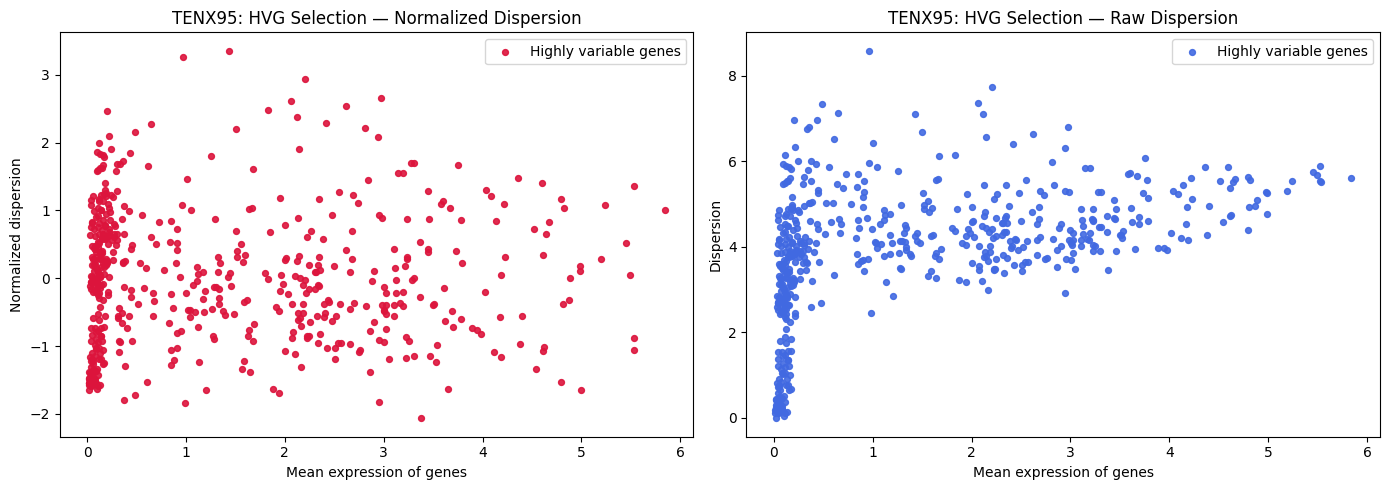

In [17]:
# HVG variance plot
hvg = adata_proc.var["highly_variable"].values
means = adata_proc.var["means"].values
dispersions = adata_proc.var["dispersions"].values
dispersions_norm = adata_proc.var["dispersions_norm"].values

plt.figure(figsize=(14, 5))

# ------------------------------------------------------------
# Panel 1: normalized dispersion
# ------------------------------------------------------------
plt.subplot(1, 2, 1)

plt.scatter(
    means[hvg],
    dispersions_norm[hvg],
    s=18,
    alpha=0.9,
    color="crimson",
    label="Highly variable genes"
)

plt.xlabel("Mean expression of genes")
plt.ylabel("Normalized dispersion")
plt.title("TENX95: HVG Selection — Normalized Dispersion")
plt.legend(frameon=True)

# ------------------------------------------------------------
# Panel 2: raw dispersion
# ------------------------------------------------------------
plt.subplot(1, 2, 2)

plt.scatter(
    means[hvg],
    dispersions[hvg],
    s=18,
    alpha=0.9,
    color="royalblue",
    label="Highly variable genes"
)

plt.xlabel("Mean expression of genes")
plt.ylabel("Dispersion")
plt.title("TENX95: HVG Selection — Raw Dispersion")
plt.legend(frameon=True)

plt.tight_layout()
plt.savefig(FIGURE_DIR / f"{SAMPLE_ID}_hvg_selection_high_contrast.png", dpi=300)
plt.show()

The high-contrast HVG plot confirms that the transcriptomic feature-selection step worked correctly. The selected genes span a useful range of mean-expression and dispersion values.

Each point represents one gene:
- Red points represent highly variable genes in normalized-dispersion plots
- Blue points represent highly variable genes in raw-dispersion plots

In [18]:
# Saving the processed AnnData
processed_h5ad_path = PROCESSED_DIR / f"{SAMPLE_ID}_processed_hvg{N_HVG}.h5ad"

adata_hvg = adata_proc[:, hvg_mask].copy()
adata_hvg.write(processed_h5ad_path)

print("Processed AnnData saved:")
print(processed_h5ad_path)
print(adata_hvg)

Processed AnnData saved:
C:\Users\Hareen\Desktop\HistoGeneAlign\data\processed\TENX95_processed_hvg2000.h5ad
AnnData object with n_obs × n_vars = 11845 × 541
    obs: 'in_tissue', 'pxl_col_in_fullres', 'pxl_row_in_fullres', 'array_col', 'array_row', 'n_genes_by_counts', 'log1p_n_genes_by_counts', 'total_counts', 'log1p_total_counts', 'pct_counts_in_top_50_genes', 'pct_counts_in_top_100_genes', 'pct_counts_in_top_200_genes', 'pct_counts_in_top_500_genes', 'total_counts_mito', 'log1p_total_counts_mito', 'pct_counts_mito'
    var: 'mito', 'n_cells_by_counts', 'mean_counts', 'log1p_mean_counts', 'pct_dropout_by_counts', 'total_counts', 'log1p_total_counts', 'highly_variable', 'means', 'dispersions', 'dispersions_norm'
    uns: 'spatial', 'log1p', 'hvg'
    obsm: 'spatial'
    layers: 'raw_counts'


### Spatial coordinate plot

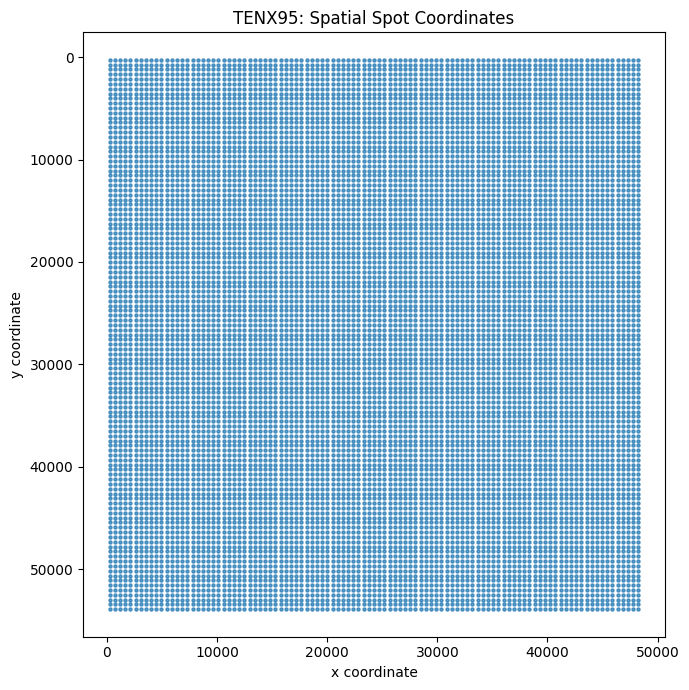

In [19]:
# Spatial coordinat scatter plot
plt.figure(figsize=(7, 7))
plt.scatter(
    spot_metadata["x"],
    spot_metadata["y"],
    s=5,
    alpha=0.7
)
plt.gca().invert_yaxis()
plt.xlabel("x coordinate")
plt.ylabel("y coordinate")
plt.title(f"{SAMPLE_ID}: Spatial Spot Coordinates")
plt.tight_layout()
plt.savefig(FIGURE_DIR / f"{SAMPLE_ID}_spatial_coordinates.png", dpi=300)
plt.show()

This plot shows the spatial layout of all TENX95 spots using their extracted `x` and `y` coordinates.

Each point represents one spatial transcriptomics spot from the `AnnData` object. The regular grid structure confirms that the coordinates were loaded correctly and that the spots follow the expected spatial-array layout.

The spot coordinates form a dense rectangular grid covering a large coordinate range.

The grid-like structure is expected because spatial transcriptomics platforms place capture locations in a fixed array pattern. The spots are evenly spaced, which indicates that the coordinate extraction from `adata.obsm["spatial"]` worked properly.

The coordinate values are very large, which strongly suggests that these are **full-resolution pixel coordinates**, not thumbnail coordinates.

This matters because full-resolution coordinates cannot be directly overlaid on a downscaled thumbnail unless they are rescaled first.

### Overlaying spatial spots on thumbnail

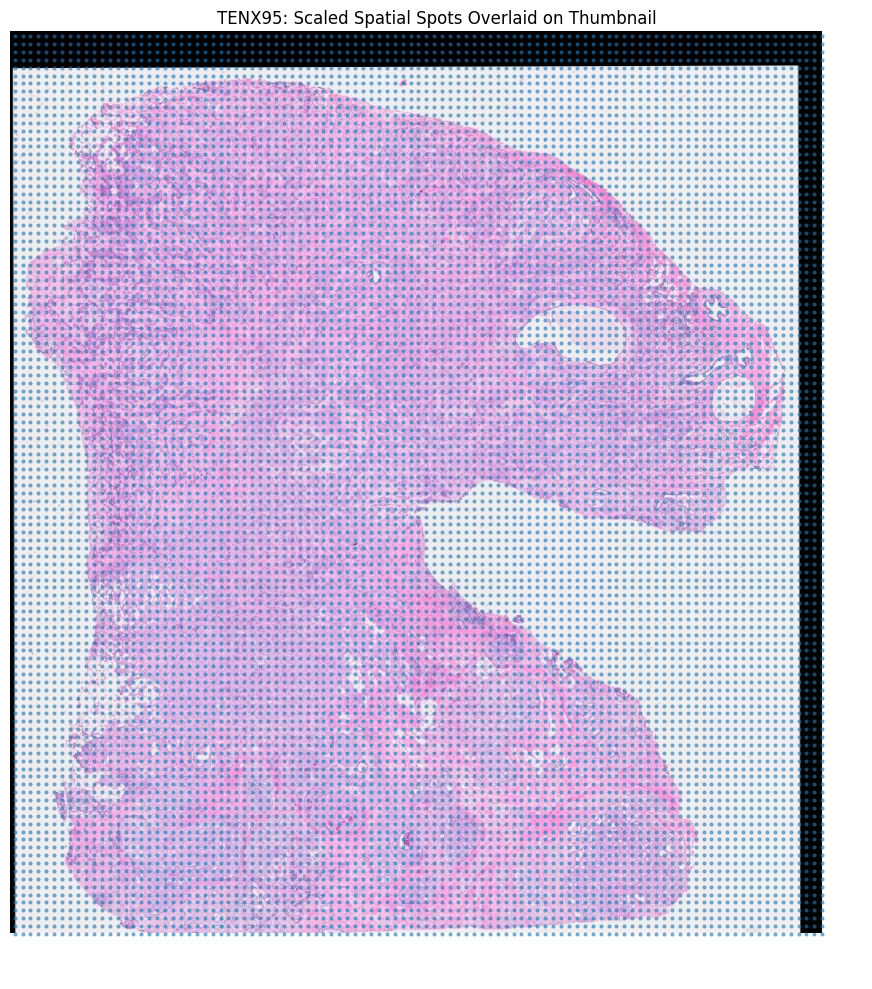

In [24]:
# Scaled overlay as coordinates are full-resolution

x_scale = thumb_w / spot_metadata["x"].max()
y_scale = thumb_h / spot_metadata["y"].max()

spot_metadata["x_thumb"] = spot_metadata["x"] * x_scale
spot_metadata["y_thumb"] = spot_metadata["y"] * y_scale

plt.figure(figsize=(10, 10))
plt.imshow(thumbnail_np)

plt.scatter(
    spot_metadata["x_thumb"],
    spot_metadata["y_thumb"],
    s=4,
    alpha=0.5
)

plt.title(f"{SAMPLE_ID}: Scaled Spatial Spots Overlaid on Thumbnail")
plt.axis("off")
plt.tight_layout()
plt.savefig(FIGURE_DIR / f"{SAMPLE_ID}_spot_overlay_thumbnail_scaled.png", dpi=300)
plt.show()

This figure overlays the TENX95 spatial transcriptomics spot grid on top of the downscaled H&E tissue thumbnail. The overlay is now visually meaningful because the full-resolution spot coordinates were scaled into thumbnail coordinate space.

Each blue point represents one spatial transcriptomics capture spot, and the background image is the H&E tissue section.

The scaled spot grid aligns correctly with the tissue image. The spots cover the full rectangular capture area, while the tissue occupies only part of that area. This is expected for spatial transcriptomics data because the capture array is rectangular, but the actual tissue section has an irregular biological shape.

This confirms that the coordinate transformation worked:

`full-resolution spatial coordinates → scaled thumbnail coordinates → correct visual overlay on H&E image`

In [26]:
# Save updated spot metadata with QC fields

spot_metadata_final_path = PROCESSED_DIR / f"{SAMPLE_ID}_spot_metadata_qc.csv"
spot_metadata.to_csv(spot_metadata_final_path, index=False)

print("Final outputs from notebook 02:")
print("1.", spot_metadata_final_path)
print("2.", gene_summary_path)
print("3.", hvg_path)
print("4.", processed_h5ad_path)
print("5. Figures saved to:", FIGURE_DIR)

Final outputs from notebook 02:
1. C:\Users\Hareen\Desktop\HistoGeneAlign\data\processed\TENX95_spot_metadata_qc.csv
2. C:\Users\Hareen\Desktop\HistoGeneAlign\data\processed\TENX95_gene_summary.csv
3. C:\Users\Hareen\Desktop\HistoGeneAlign\data\processed\TENX95_hvg_2000.txt
4. C:\Users\Hareen\Desktop\HistoGeneAlign\data\processed\TENX95_processed_hvg2000.h5ad
5. Figures saved to: C:\Users\Hareen\Desktop\HistoGeneAlign\outputs\figures
